In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict
import pickle
import dask.dataframe as dd
import seaborn as sns
import matplotlib.pyplot as plt
import random

In [2]:
# Adjusted function to correctly map exons to genes by considering mRNA as intermediates
def parse_gff3(filepath):
    gene_data = []
    mrna_data = []
    exon_data = []

    with open(filepath, 'r') as file:
        for line in file:
            if line.startswith('#'):
                continue
            parts = line.strip().split('\t')
            chrom, source, feature, start, end, score, strand, phase, attributes = parts
            attr_dict = {item.split('=')[0]: item.split('=')[1] for item in attributes.split(';') if '=' in item}

            if feature == 'gene':
                gene_id = attr_dict.get('ID', '')
                gene_name = attr_dict.get('Name', gene_id.split('.')[0])
                biotype = attr_dict.get('Note', 'unknown')
                gene_data.append((chrom, start, end, gene_name, biotype, gene_id))
            elif feature == 'mRNA':
                mrna_id = attr_dict.get('ID', '')
                parent_id = attr_dict.get('Parent', '')
                mrna_data.append((parent_id, mrna_id))
            elif feature == 'exon' and 'Parent' in attr_dict:
                parent_id = attr_dict['Parent']
                exon_data.append((parent_id, start, end))

    gene_df = pd.DataFrame(gene_data, columns=['chrom', 'gene_start', 'gene_end', 'gene_symbol', 'biotype', 'gene_id'])
    mrna_df = pd.DataFrame(mrna_data, columns=['gene_id', 'mrna_id'])
    exon_df = pd.DataFrame(exon_data, columns=['mrna_id', 'exon_start', 'exon_end'])

    merged_df = gene_df.merge(mrna_df, on='gene_id').merge(exon_df, on='mrna_id')
    merged_df['exon_chromstart'] = merged_df.groupby('gene_id')['exon_start'].transform(lambda x: ','.join(x))
    merged_df['exon_chromend'] = merged_df.groupby('gene_id')['exon_end'].transform(lambda x: ','.join(x))

    final_df = merged_df.drop(['mrna_id', 'exon_start', 'exon_end'], axis=1).drop_duplicates()

    return final_df

In [3]:
#gff3_formatted = parse_gff3('../key_files/TAIR10_GFF3_genes_transposons.gff')

In [4]:
#gff3_formatted['chrom'].unique()

## discard the mithocondrial and chloroplast
#gff3_formatted = gff3_formatted[gff3_formatted['chrom'].isin(['Chr1', 'Chr2', 'Chr3', 'Chr4', 'Chr5'])]

#gff3_formatted['chrom'] = gff3_formatted['chrom'].str.replace('Chr', '').astype(int)

#gff3_formatted.to_csv(path + 'data-intermediate/TAIR10_GFF3_genes_transposons_formatted4topr.csv')

In [2]:
og = pd.read_csv('../key_files/TAIR10_GFF3_genes_transposons.gff', sep = '\t', header=None)

In [3]:
og = og[og[8].str.contains('protein_coding_gene')]

In [4]:
og.to_csv('../key_files/TAIR10_GFF3_genes.gff', sep = '\t', header=None, index=None)

In [6]:
gff3_formatted = pd.read_csv('../key_files/TAIR10_GFF3_genes_transposons_formatted4topr.csv')

In [7]:
gff3_formatted = gff3_formatted.drop('Unnamed: 0',axis=1)

In [8]:
gff3_formatted.dtypes

chrom               int64
gene_start          int64
gene_end            int64
gene_symbol        object
biotype            object
gene_id            object
exon_chromstart    object
exon_chromend      object
dtype: object

In [9]:
new = pd.read_csv('tair_annotations_topr.tsv', sep='\t')

In [10]:
new = new[new['chrom'].isin(['Chr1', 'Chr2', 'Chr3', 'Chr4', 'Chr5'])]

In [11]:
new['chrom'] = new['chrom'].str.replace('Chr', '').astype(int)

AttributeError: Can only use .str accessor with string values!

In [13]:
new.to_csv('tair_annotations_topr.tsv', sep='\t', index=None)

NameError: name 'new' is not defined

In [ ]:
## gemma 1137 genomes 

In [12]:
pvalues_gemma = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/gea_grene-net/gwas/allele_assoc_runs/lmm_gemma/bio1/output/results_lmm_maf.csv')

In [12]:
pvalues_gemma['CHROM'] = pvalues_gemma['rs'].str.split('_').str[0]
pvalues_gemma['POS'] = pvalues_gemma['rs'].str.split('_').str[1]

In [13]:
pvalues_gemma = pvalues_gemma[['p_wald', 'CHROM', 'POS']]

In [14]:
pvalues_gemma.columns = ['P', 'CHROM', 'POS' ]

In [16]:
pvalues_gemma.to_csv(f'gemma1137_bio1_4topr.csv',index=None)

In [20]:
pvalues_gemma = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/gea_grene-net/gwas/allele_assoc_runs/only_grenenet/lmm_gemma/bio1/output/results_lmm_maf.csv')

In [21]:
pvalues_gemma['CHROM'] = pvalues_gemma['rs'].str.split('_').str[0]
pvalues_gemma['POS'] = pvalues_gemma['rs'].str.split('_').str[1]

In [22]:
pvalues_gemma = pvalues_gemma[['p_wald', 'CHROM', 'POS']]

In [23]:
pvalues_gemma.columns = ['P', 'CHROM', 'POS' ]

In [24]:
pvalues_gemma.to_csv(f'gemma231_bio1_4topr.csv',index=None)

In [2]:
#pvalues_lfmm = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/lfmm_full/lfmm_fullresults_all_k/lfmm_bio1_k25_results.csv'
#pvalues_lfmm = pd.read_csv(pvalues_lfmm)

In [19]:
pvalues_lfmm = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/lfmm_full_last_gen/lfmm_fullresults_all_k/lfmm_bio1_k16_results.csv'
pvalues_lfmm = pd.read_csv(pvalues_lfmm)

In [20]:
#pvalues_linages = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/linages_wza_picmin/kendall_0_w_id_n_blocks.csv'
#pvalues_linages = pd.read_csv(pvalues_linages)

In [21]:
#pvalues_lfmm = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/lfmm_full/lfmm_fullresults_all_k/lfmm_bio1_k25_results.csv'
#pvalues_lfmm = pd.read_csv(pvalues_lfmm)

lfmm_result_4topr = pvalues_lfmm[['snp_id', 'p_value']]

lfmm_result_4topr['CHROM'] = lfmm_result_4topr['snp_id'].str.split('_').str[0]
lfmm_result_4topr['POS'] = lfmm_result_4topr['snp_id'].str.split('_').str[1]

lfmm_result_4topr = lfmm_result_4topr[['p_value', 'CHROM', 'POS']]

lfmm_result_4topr.columns = ['P', 'CHROM', 'POS' ]
## get rid of everything that is not below the treshhold
#lfmm_result_4topr = lfmm_result_4topr[lfmm_result_4topr['P'] < 0.0001]
lfmm_result_4topr.to_csv(f'lfmm_bio1_4topr_last_gen.csv',index=None)

/tmp/ipykernel_2616686/4223356288.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lfmm_result_4topr['CHROM'] = lfmm_result_4topr['snp_id'].str.split('_').str[0]


In [22]:
pvalues_kendall = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/kendall_tau_last_gen/kendall_corr_bio1.csv'
pvalues_kendall = pd.read_csv(pvalues_kendall)

In [23]:
pvalues_kendall = pvalues_kendall[['K_tau_p', 'chrom', 'pos']]

In [24]:
pvalues_kendall.columns = ['P', 'CHROM', 'POS' ]

In [25]:
pvalues_kendall['POS'] = pvalues_kendall['POS'].astype(int)

In [26]:
#pvalues_kendall = pvalues_kendall[pvalues_kendall['P'] < 0.0001]

In [27]:
pvalues_kendall.to_csv(f'kendall_bio1_4topr_last_gen.csv',index=None)

In [28]:
pvalues_binom = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/binomial_regression_lastgen/binomial_reg_lastgen_wmaf_bio1.csv'
pvalues_binom = pd.read_csv(pvalues_binom)

In [29]:
pvalues_binom['CHROM'] = pvalues_binom['snp_id'].str.split('_').str[0]
pvalues_binom['POS'] = pvalues_binom['snp_id'].str.split('_').str[1]

In [30]:
pvalues_binom = pvalues_binom[['pvalue', 'CHROM', 'POS']]

In [31]:
pvalues_binom.columns = ['P', 'CHROM', 'POS' ]

In [32]:
pvalues_binom['POS'] = pvalues_binom['POS'].astype(int)

In [33]:
pvalues_binom.to_csv('binom_bio1_4topr_last_gen.csv',index=None)

In [109]:
#pvalues_binom = pvalues_binom[pvalues_binom['P'] < 0.0001]

In [99]:
#def calculate_genomic_inflation_factor(p_values):
    # Convert p-values to chi-squared statistics
#    chi_squared_stats = -2 * np.log(p_values)
    
    # Calculate lambda (genomic inflation factor)
#    lambda_gif = np.median(chi_squared_stats) / chi2.ppf(0.5, 1)
    
#    return lambda_gif

In [100]:
def calculate_genomic_inflation_factor(p_values):
    """Calculate λ_gc from Wald test p-values (binomial/linear regression)."""
    # Convert p-values to chi-squared stats (Wald test)
    chi_squared_stats = chi2.isf(p_values, df=1)  # Equivalent to chi2.ppf(1 - p_values, df=1)
    
    # Expected median of chi-squared (df=1) under null
    expected_median = chi2.ppf(0.5, df=1)  # ≈0.454936
    
    # Genomic inflation factor
    lambda_gc = np.median(chi_squared_stats) / expected_median
    
    return lambda_gc

In [101]:
import numpy as np
from scipy.stats import chi2



def adjust_p_values(p_values, lambda_gif):
    # Adjust the chi-squared values
    adjusted_chi_squared = -2 * np.log(p_values) / lambda_gif
    
    # Convert adjusted chi-squared values back to p-values
    adjusted_p_values = np.exp(-adjusted_chi_squared / 2)
    
    return adjusted_p_values


In [102]:
# Example usage
p_values = pvalues_binom['P']  # Example p-values
lambda_gif = calculate_genomic_inflation_factor(p_values)
print("Genomic Inflation Factor:", lambda_gif)

Genomic Inflation Factor: 100.23266697260561


In [79]:

adjusted_p_values = adjust_p_values(p_values, 100)

/home/tbellagio/miniforge3/envs/pipeline_snakemake/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [66]:
pvalues_binom.to_csv(f'binom_bio1_4topr_last_gen_inff15.csv',index=None)

In [ ]:
file_name = ''

In [51]:
#!/usr/bin/env python

import sys
import re

if len(sys.argv) != 2:
    print("Usage: {} <file>".format(sys.argv[0]))
    sys.exit(1)



try:
    with open(file_name, 'r') as fh:
        genes = {}
        for line in fh:
            if not line.startswith('#'):
                columns = line.strip().split('\t')
                chrom, start, end = columns[0], columns[3], columns[4]

                if columns[2] == 'exon':
                    gene_name = None
                    match = re.search(r'ID=([^;]+);.*Parent=([^;]+)', columns[8])
                    if match:
                        gene_name = match.group(2)

                    if gene_name in genes:
                        if "exon_chromstart" in genes[gene_name]:
                            genes[gene_name]["exon_chromstart"].append(start)
                        else:
                            genes[gene_name]["exon_chromstart"] = [start]

                        if "exon_chromend" in genes[gene_name]:
                            genes[gene_name]["exon_chromend"].append(end)
                        else:
                            genes[gene_name]["exon_chromend"] = [end]

                elif columns[2] == 'gene':
                    gene_name, gene_type = None, None
                    match = re.search(r'ID=([^;]+);.*biotype=([^;]+)', columns[8])
                    if match:
                        gene_name, gene_type = match.group(1), match.group(2)

                    if gene_name not in genes:
                        genes[gene_name] = {
                            "gene_start": start,
                            "gene_end": end,
                            "chr": chrom,
                            "biotype": gene_type
                        }

except FileNotFoundError:
    print("File not found: {}".format(file_name))
    sys.exit(1)

# Print the output
print("\t".join(["chrom", "gene_start", "gene_end", "gene_symbol", "biotype", "exon_chromstart", "exon_chromend"]))
for gene, data in genes.items():
    if not gene:
        continue
    exon_starts = ",".join(data.get("exon_chromstart", []))
    exon_ends = ",".join(data.get("exon_chromend", []))
    print("\t".join([data["chr"], data["gene_start"], data["gene_end"], gene, data["biotype"], exon_starts, exon_ends]))


Usage: /home/tbellagio/miniforge3/envs/pipeline_snakemake/lib/python3.9/site-packages/ipykernel_launcher.py <file>


SystemExit: 1

/home/tbellagio/miniforge3/envs/pipeline_snakemake/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3450: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [36]:
pvalues_lfmm_file = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/lfmm_full/lfmm_fullresults_all_k/lfmm_bio1_k25_results.csv'
pvalues_lfmm = pd.read_csv(pvalues_lfmm_file)

In [37]:
lfmm_result_4topr = pvalues_lfmm[['snp_id', 'p_value']]

lfmm_result_4topr['CHROM'] = lfmm_result_4topr['snp_id'].str.split('_').str[0]
lfmm_result_4topr['POS'] = lfmm_result_4topr['snp_id'].str.split('_').str[1]

/tmp/ipykernel_4056255/295300719.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lfmm_result_4topr['CHROM'] = lfmm_result_4topr['snp_id'].str.split('_').str[0]


In [38]:
lfmm_result_4topr

,snp_id,p_value,CHROM,POS
0,1_346,7.657514e-01,1,346
1,1_353,2.399266e-02,1,353
2,1_363,6.970041e-01,1,363
3,1_395,7.417576e-01,1,395
4,1_396,7.417576e-01,1,396
...,...,...,...,...
1054569,5_26975078,3.863299e-02,5,26975078
1054570,5_26975121,2.719072e-01,5,26975121
1054571,5_26975148,2.719072e-01,5,26975148
1054572,5_26975272,8.939716e-01,5,26975272


In [16]:
import gwaslab as gl
# load plink2 output  2:11531000-11535000 

In [39]:
mysumstats = gl.Sumstats(lfmm_result_4topr,
             snpid="snp_id",
             chrom="CHROM",
             pos="POS",
             p="p_value",
)

2024/09/20 15:48:12 GWASLab v3.4.46 https://cloufield.github.io/gwaslab/
2024/09/20 15:48:12 (C) 2022-2024, Yunye He, Kamatani Lab, MIT License, gwaslab@gmail.com
2024/09/20 15:48:12 Start to initialize gl.Sumstats from pandas DataFrame ...
2024/09/20 15:48:12  -Reading columns          : POS,p_value,CHROM,snp_id
2024/09/20 15:48:12  -Renaming columns to      : POS,P,CHR,SNPID
2024/09/20 15:48:12  -Current Dataframe shape : 1054574  x  4
2024/09/20 15:48:13  -Initiating a status column: STATUS ...
2024/09/20 15:48:13  #WARNING! Version of genomic coordinates is unknown...
2024/09/20 15:48:13 Start to reorder the columns...v3.4.46
2024/09/20 15:48:13  -Current Dataframe shape : 1054574 x 5 ; Memory usage: 56.15 MB
2024/09/20 15:48:13  -Reordering columns to    : SNPID,CHR,POS,P,STATUS
2024/09/20 15:48:13 Finished reordering the columns.
2024/09/20 15:48:13  -Column  : SNPID  CHR    POS    P       STATUS  
2024/09/20 15:48:13  -DType   : object string object float64 category
2024/09/20 1

In [41]:
mysumstats.data

,SNPID,CHR,POS,P,STATUS
0,1_346,1,346,7.657514e-01,9999999
1,1_353,1,353,2.399266e-02,9999999
2,1_363,1,363,6.970041e-01,9999999
3,1_395,1,395,7.417576e-01,9999999
4,1_396,1,396,7.417576e-01,9999999
...,...,...,...,...,...
1054569,5_26975078,5,26975078,3.863299e-02,9999999
1054570,5_26975121,5,26975121,2.719072e-01,9999999
1054571,5_26975148,5,26975148,2.719072e-01,9999999
1054572,5_26975272,5,26975272,8.939716e-01,9999999


In [56]:
lfmm_result_4topr

,snp_id,p_value,CHROM,POS
0,1_346,7.657514e-01,1,346
1,1_353,2.399266e-02,1,353
2,1_363,6.970041e-01,1,363
3,1_395,7.417576e-01,1,395
4,1_396,7.417576e-01,1,396
...,...,...,...,...
1054569,5_26975078,3.863299e-02,5,26975078
1054570,5_26975121,2.719072e-01,5,26975121
1054571,5_26975148,2.719072e-01,5,26975148
1054572,5_26975272,8.939716e-01,5,26975272


In [61]:
pvalues_lfmm = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/lfmm_full/lfmm_fullresults_all_k/lfmm_bio1_k25_results.csv'
pvalues_lfmm = pd.read_csv(pvalues_lfmm)

lfmm_result_4topr = pvalues_lfmm[['snp_id', 'p_value']]

lfmm_result_4topr['chrom'] = lfmm_result_4topr['snp_id'].str.split('_').str[0].astype(int)
lfmm_result_4topr['pos'] = lfmm_result_4topr['snp_id'].str.split('_').str[1].astype(int)

/tmp/ipykernel_4056255/4160621341.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lfmm_result_4topr['chrom'] = lfmm_result_4topr['snp_id'].str.split('_').str[0].astype(int)


In [62]:
lfmm_result_4topr

,snp_id,p_value,chrom,pos
0,1_346,7.657514e-01,1,346
1,1_353,2.399266e-02,1,353
2,1_363,6.970041e-01,1,363
3,1_395,7.417576e-01,1,395
4,1_396,7.417576e-01,1,396
...,...,...,...,...
1054569,5_26975078,3.863299e-02,5,26975078
1054570,5_26975121,2.719072e-01,5,26975121
1054571,5_26975148,2.719072e-01,5,26975148
1054572,5_26975272,8.939716e-01,5,26975272


In [63]:
# Example GWAS DataFrame with chromosome (chrom), position (pos), p-value, etc.
gwas_df = pd.DataFrame({
    'chrom': [1, 1, 2],  # Example chromosomes
    'pos': [5000, 13000, 11500000],  # Example positions
    'p_value': [0.001, 0.05, 0.0001]  # Example p-values
})

# Merge the GWAS data with the gene annotations based on chromosome and position
def map_gwas_to_genes(gwas, gff):
    # Performing a merge where GWAS positions fall between gene start and end
    merged_df = pd.merge_asof(gwas.sort_values('pos'), 
                              gff.sort_values('gene_start'), 
                              by='chrom', 
                              left_on='pos', 
                              right_on='gene_start',
                              direction='forward')
    
    # Filter rows where the GWAS position actually falls within gene start and end
    merged_df = merged_df[(merged_df['pos'] >= merged_df['gene_start']) & 
                          (merged_df['pos'] <= merged_df['gene_end'])]
    
    return merged_df

# Apply the function
mapped_df = map_gwas_to_genes(lfmm_result_4topr, gff3_formatted)

# Check the mapped DataFrame
print(mapped_df.head())


         snp_id       p_value  chrom     pos  gene_start  gene_end  \
351     3_19592  7.367936e-02      3   19592     19592.0   20719.0   
2825    4_97499  3.041381e-01      4   97499     97499.0   99353.0   
3938   3_119618  1.079622e-02      3  119618    119618.0  119917.0   
15265  2_353457  3.528899e-07      2  353457    353457.0  355522.0   
15483  4_359315  8.657583e-01      4  359315    359315.0  360493.0   

      gene_symbol              biotype    gene_id  \
351     AT3G01070  protein_coding_gene  AT3G01070   
2825    AT4G00231  protein_coding_gene  AT4G00231   
3938    AT3G01331  protein_coding_gene  AT3G01331   
15265   AT2G01818  protein_coding_gene  AT2G01818   
15483   AT4G00860  protein_coding_gene  AT4G00860   

                   exon_chromstart                exon_chromend  
351                    19592,20110                  19827,20719  
2825                   97499,98203                  98107,99353  
3938                        119618                       11991

In [64]:
mapped_df

,snp_id,p_value,chrom,pos,gene_start,gene_end,gene_symbol,biotype,gene_id,exon_chromstart,exon_chromend
351,3_19592,7.367936e-02,3,19592,19592.0,20719.0,AT3G01070,protein_coding_gene,AT3G01070,"19592,20110","19827,20719"
2825,4_97499,3.041381e-01,4,97499,97499.0,99353.0,AT4G00231,protein_coding_gene,AT4G00231,"97499,98203","98107,99353"
3938,3_119618,1.079622e-02,3,119618,119618.0,119917.0,AT3G01331,protein_coding_gene,AT3G01331,119618,119917
15265,2_353457,3.528899e-07,2,353457,353457.0,355522.0,AT2G01818,protein_coding_gene,AT2G01818,"355362,354648,354355,353457","355522,354914,354513,353785"
15483,4_359315,8.657583e-01,4,359315,359315.0,360493.0,AT4G00860,protein_coding_gene,AT4G00860,"360381,359772,359315","360493,359875,359693"
...,...,...,...,...,...,...,...,...,...,...,...
1048121,1_29472892,5.879353e-01,1,29472892,29472892.0,29473863.0,AT1G78340,protein_coding_gene,AT1G78340,"29473483,29472892","29473863,29473387"
1050814,1_29815506,8.454457e-01,1,29815506,29815506.0,29819104.0,AT1G79270,protein_coding_gene,AT1G79270,"29815506,29816607,29816790,29816998,29817162,2...","29816190,29816677,29816907,29817068,29817518,2..."
1052299,1_30022260,2.103851e-02,1,30022260,30022260.0,30027443.0,AT1G79820,protein_coding_gene,AT1G79820,"30027290,30026666,30026307,30025966,30025727,3...","30027377,30026790,30026418,30026033,30025859,3..."
1054076,1_30339323,6.181362e-01,1,30339323,30339323.0,30340247.0,AT1G80730,protein_coding_gene,AT1G80730,30339323,30340247


In [66]:
# Assuming 'mysumstats' is the summary statistics object you're using in gwaslab
mysumstats.plot_mqq(mode="r", 
                    anno=True, 
                    region=(2, 11531000, 11535000), 
                    region_grid=True, 
                    build='custom', 
                    annotation_df=mapped_df[['chrom', 'gene_symbol', 'pos']])


NameError: name 'gff_df' is not defined

2024/09/20 16:09:30 Start to create MQQ plot...v3.4.46:
2024/09/20 16:09:30  -Genomic coordinates version: custom...
2024/09/20 16:09:30  -Genome-wide significance level to plot is set to 5e-08 ...
2024/09/20 16:09:30  -Raw input contains 1054574 variants...
2024/09/20 16:09:30  -MQQ plot layout mode is : r
2024/09/20 16:09:30  -Region to plot : chr1:3631-5899.
2024/09/20 16:09:30  -Extract SNPs in region : chr1:3631-5899...
2024/09/20 16:09:30  -Extract SNPs in specified regions: 4
2024/09/20 16:09:30 Finished loading specified columns from the sumstats.
2024/09/20 16:09:30 Start data conversion and sanity check:
2024/09/20 16:09:30  -Removed 0 variants with nan in CHR or POS column ...
2024/09/20 16:09:30  -Removed 0 variants with CHR <=0...
2024/09/20 16:09:30  -Removed 0 variants with nan in P column ...
2024/09/20 16:09:30  -Sanity check after conversion: 0 variants with P value outside of (0,1] will be removed...
2024/09/20 16:09:30  -Sumstats P values are being converted to -log

(<Figure size 3000x2000 with 3 Axes>, <gwaslab.g_Log.Log at 0x7f2966568c70>)

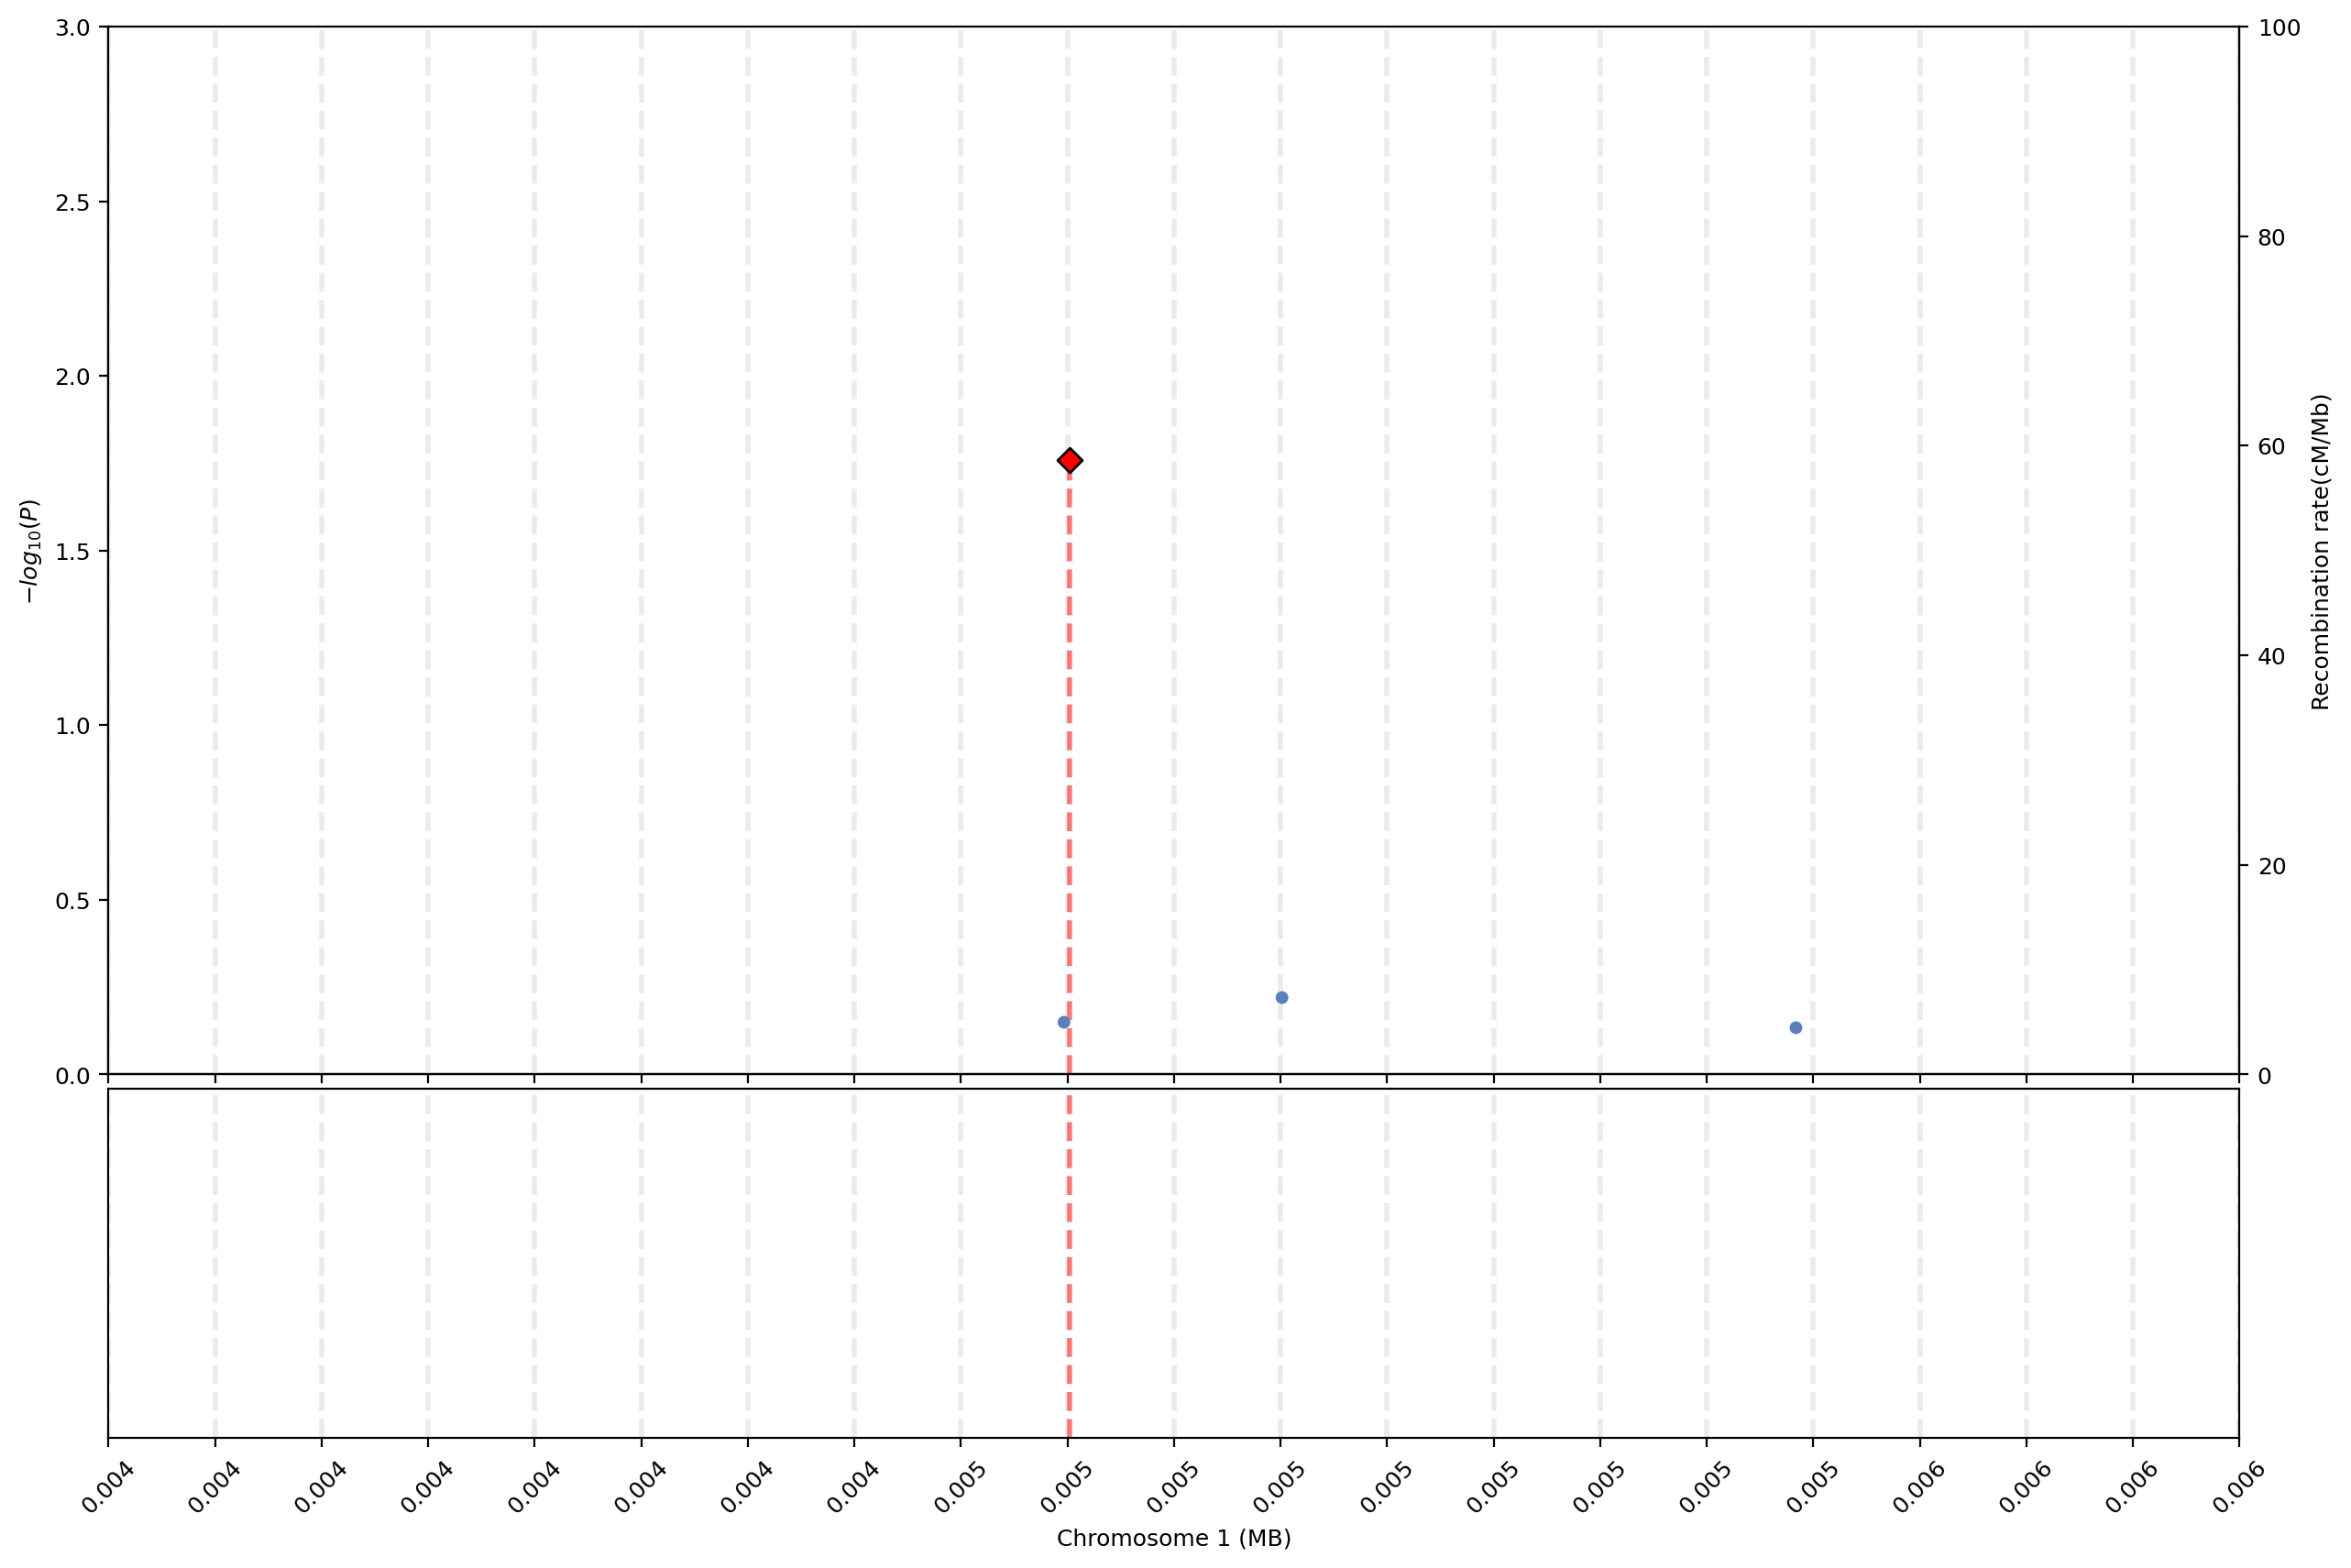

In [67]:
# Example: Extract gene symbols and their coordinates
genes_of_interest = gff3_formatted[['gene_symbol', 'chrom', 'gene_start', 'gene_end']]

# Extract coordinates for a specific gene
gene_symbol = 'AT1G01010'
gene_info = genes_of_interest[genes_of_interest['gene_symbol'] == gene_symbol]
chrom = gene_info['chrom'].values[0]
start = gene_info['gene_start'].values[0]
end = gene_info['gene_end'].values[0]

# Then you can plot and highlight this region in gwaslab
mysumstats.plot_mqq(mode="r", 
                    anno=True, 
                    region=(chrom, start, end),
                    region_grid=True,
                    build='custom')

In [44]:
#check SNPID,rsID,CHR,POS,EA, NEA and statistics
mysumstats.basic_check()

2024/09/20 15:50:57 Start to check SNPID/rsID...v3.4.46
2024/09/20 15:50:57  -Current Dataframe shape : 1054574 x 5 ; Memory usage: 56.15 MB
2024/09/20 15:50:57  -Checking SNPID data type...
2024/09/20 15:50:57  -Converting SNPID to pd.string data type...
2024/09/20 15:50:57  -Checking if SNPID is CHR:POS:NEA:EA...(separator: - ,: , _)
2024/09/20 15:51:01 Finished checking SNPID/rsID.
2024/09/20 15:51:01 Start to fix chromosome notation (CHR)...v3.4.46
2024/09/20 15:51:01  -Current Dataframe shape : 1054574 x 5 ; Memory usage: 56.15 MB
2024/09/20 15:51:01  -Checking CHR data type...
2024/09/20 15:51:01  -Variants with standardized chromosome notation: 1054574
2024/09/20 15:51:01  -All CHR are already fixed...
2024/09/20 15:51:03 Finished fixing chromosome notation (CHR).
2024/09/20 15:51:03 Start to fix basepair positions (POS)...v3.4.46
2024/09/20 15:51:03  -Current Dataframe shape : 1054574 x 5 ; Memory usage: 57.15 MB
2024/09/20 15:51:03  -Removing thousands separator "," or underba

In [50]:
mysumstats.infer_build()

2024/09/20 15:58:11 Start to infer genome build version using hapmap3 SNPs...v3.4.46
2024/09/20 15:58:11  -Current Dataframe shape : 1054574 x 5 ; Memory usage: 58.16 MB
2024/09/20 15:58:11 Start to infer genome build version using hapmap3 SNPs...
2024/09/20 15:58:11  -Loading Hapmap3 variants data...
2024/09/20 15:58:13  -CHR:POS will be used for matching...
2024/09/20 15:58:16  -Matching variants for hg19: num_hg19 =  517
2024/09/20 15:58:16  -Matching variants for hg38: num_hg38 =  532
2024/09/20 15:58:16  #WARNING! Please be cautious due to the limited number of variants.
2024/09/20 15:58:16  -Since num_hg19 << num_hg38, assigning genome build hg38...
2024/09/20 15:58:18 Finished inferring genome build version using hapmap3 SNPs.


2024/09/20 16:01:47 Start to create MQQ plot...v3.4.46:
2024/09/20 16:01:47  -Genomic coordinates version: custom...
2024/09/20 16:01:47  -Genome-wide significance level to plot is set to 5e-08 ...
2024/09/20 16:01:47  -Raw input contains 1054574 variants...
2024/09/20 16:01:47  -MQQ plot layout mode is : r
2024/09/20 16:01:47  -Region to plot : chr2:11531000-11535000.
2024/09/20 16:01:47  -Extract SNPs in region : chr2:11531000-11535000...
2024/09/20 16:01:47  -Extract SNPs in specified regions: 62
2024/09/20 16:01:48 Finished loading specified columns from the sumstats.
2024/09/20 16:01:48 Start data conversion and sanity check:
2024/09/20 16:01:48  -Removed 0 variants with nan in CHR or POS column ...
2024/09/20 16:01:48  -Removed 0 variants with CHR <=0...
2024/09/20 16:01:48  -Removed 0 variants with nan in P column ...
2024/09/20 16:01:48  -Sanity check after conversion: 0 variants with P value outside of (0,1] will be removed...
2024/09/20 16:01:48  -Sumstats P values are being 

(<Figure size 3000x2000 with 3 Axes>, <gwaslab.g_Log.Log at 0x7f2966568c70>)

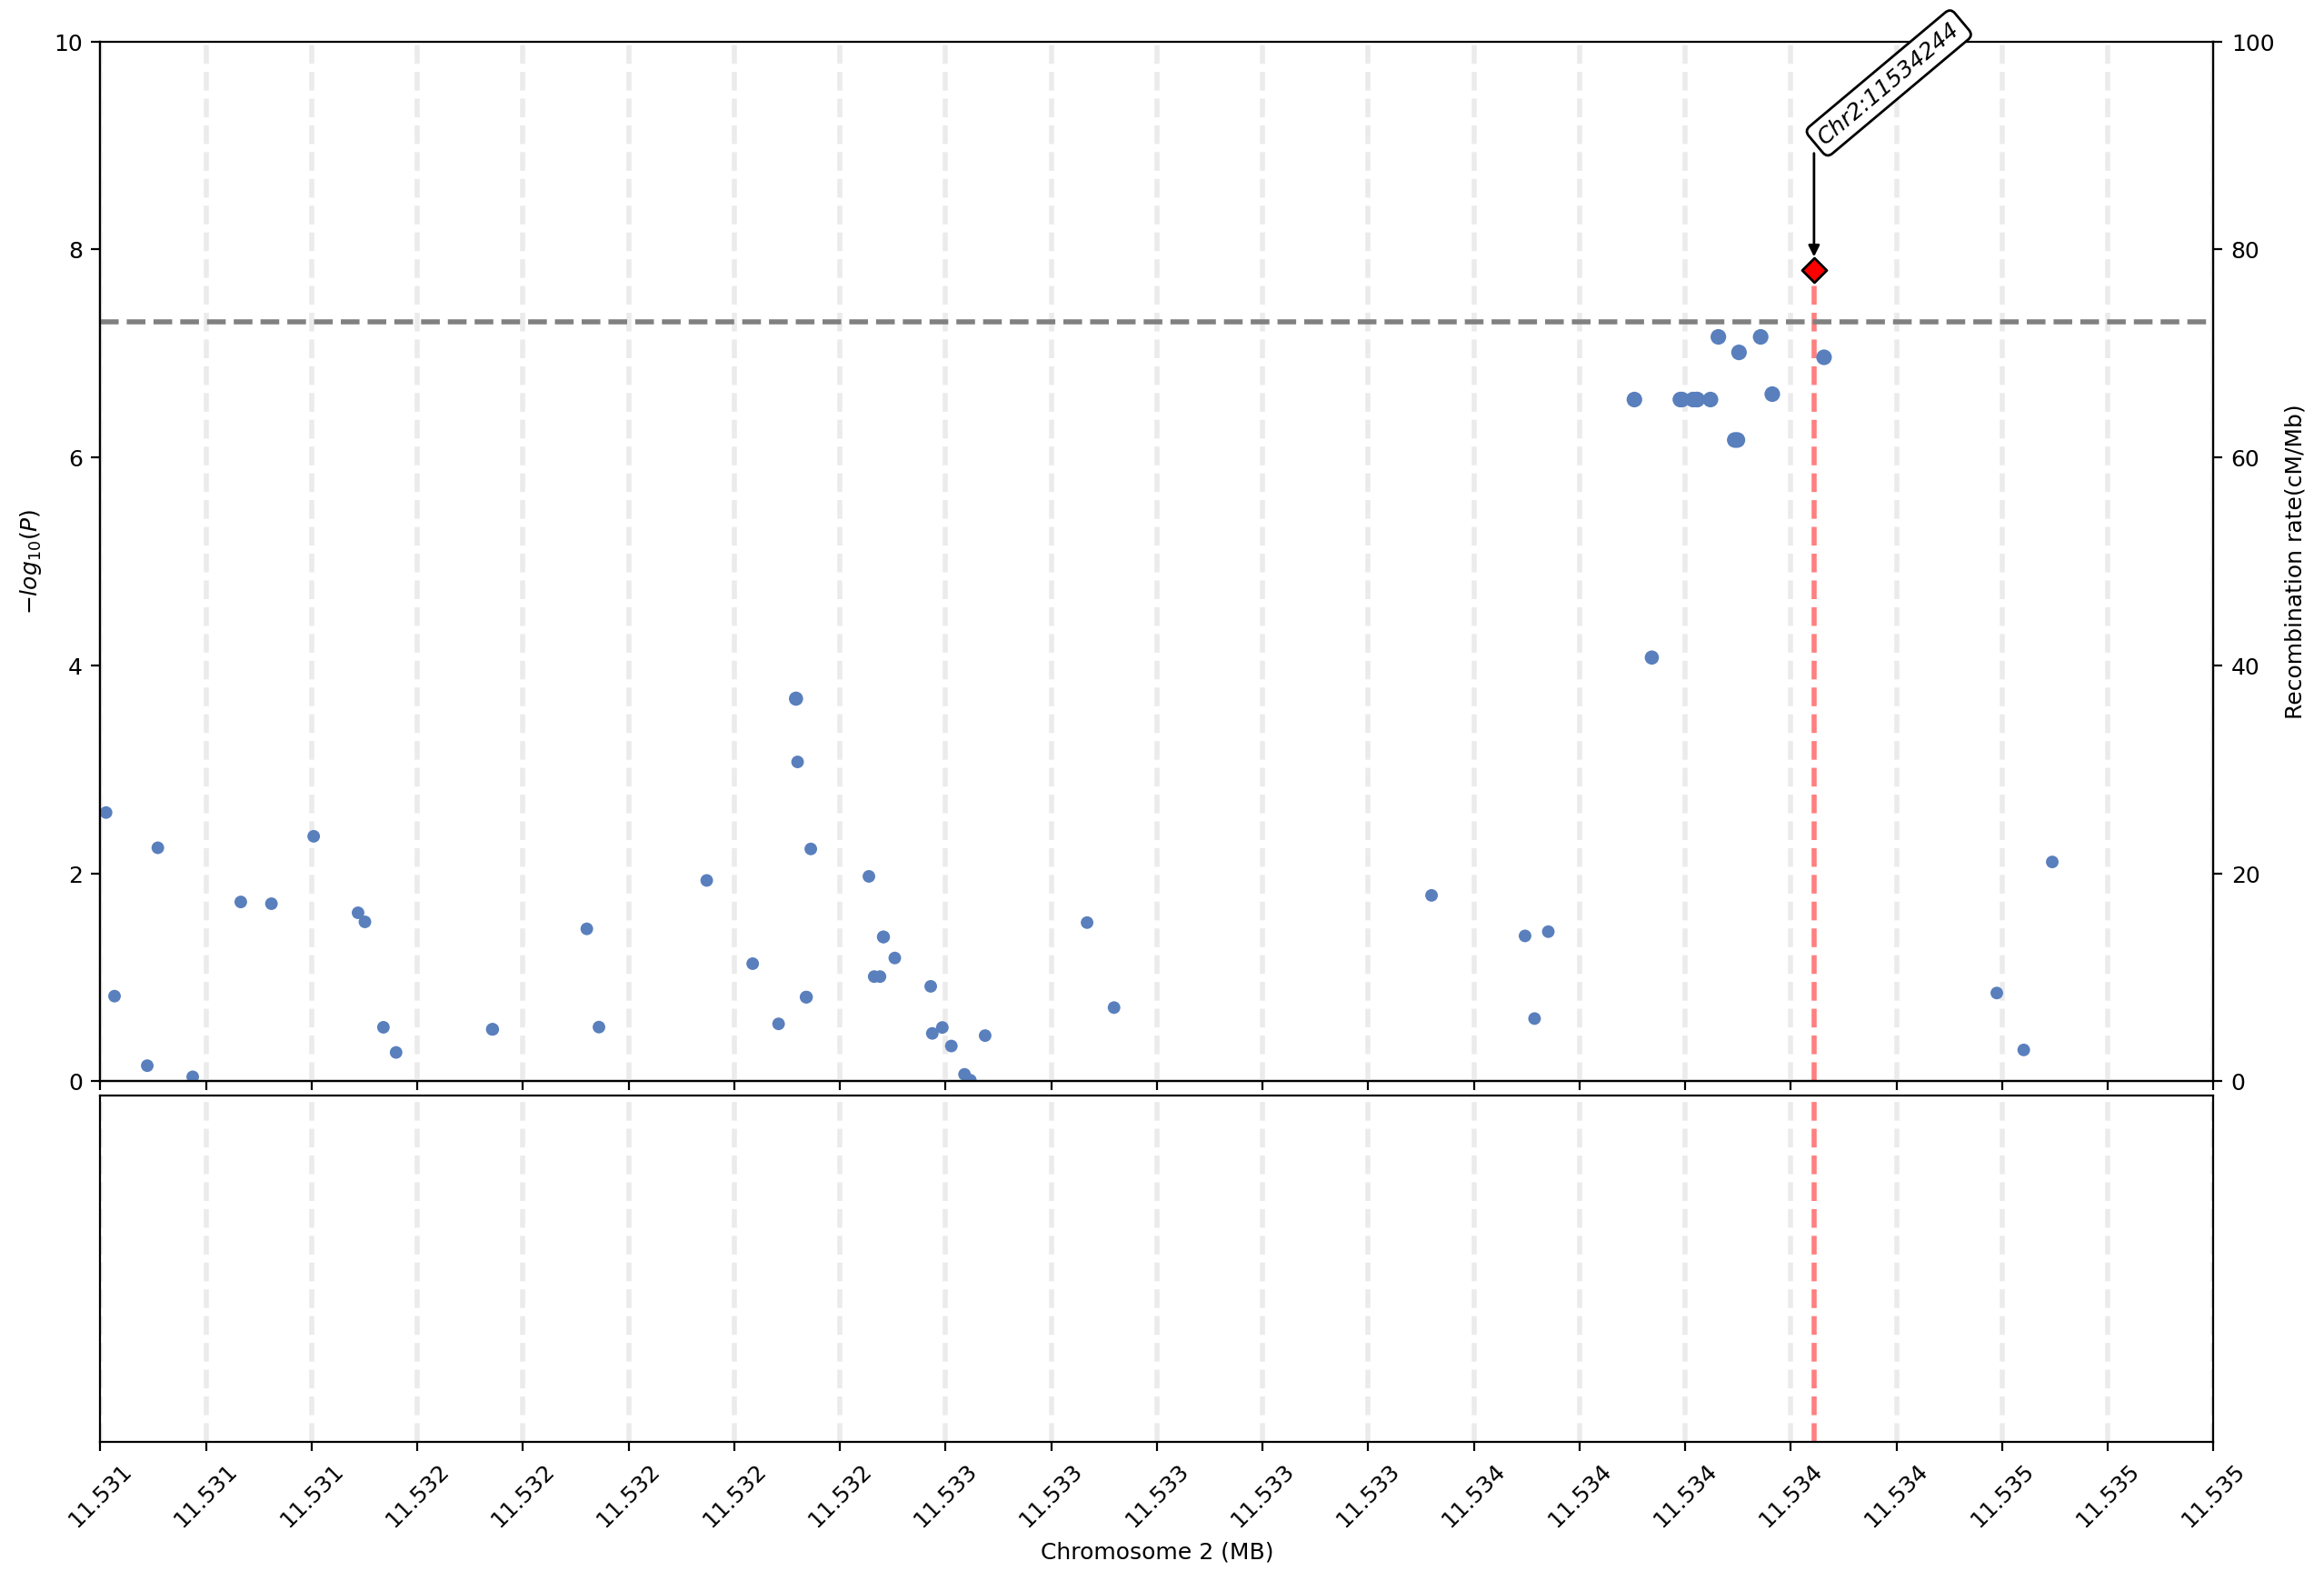

In [52]:
mysumstats.plot_mqq(mode="r",anno=True,region=(2,11531000,11535000),region_grid=True,
                  build='custom')